# Notebook 4: Deep Exploratory Data Analysis (EDA)
**Project**: Loan Approval Prediction & Banking Analytics

---
## 1. Introduction
In this notebook, we perform a deep Exploratory Data Analysis (EDA) to understand distributions, relationships, and trends. We read data directly from the SQLite database.

### Analytical Scope:
1. **Univariate Analysis**: Distribution of key variables.
2. **Bivariate Analysis**: Analysis of features against the target variable (`Loan_Status`).
3. **Multivariate Analysis**: Interaction between multiple features and target labels.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Set seaborn style for corporate presentation
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 16

# Connect and read from SQLite database
db_path = os.path.join("..", "SQL", "loan_database.db")
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM loan_cleaned", conn)
conn.close()

print(f"Loaded {df.shape[0]} rows for EDA.")

Loaded 614 rows for EDA.


## 2. Target Variable Analysis

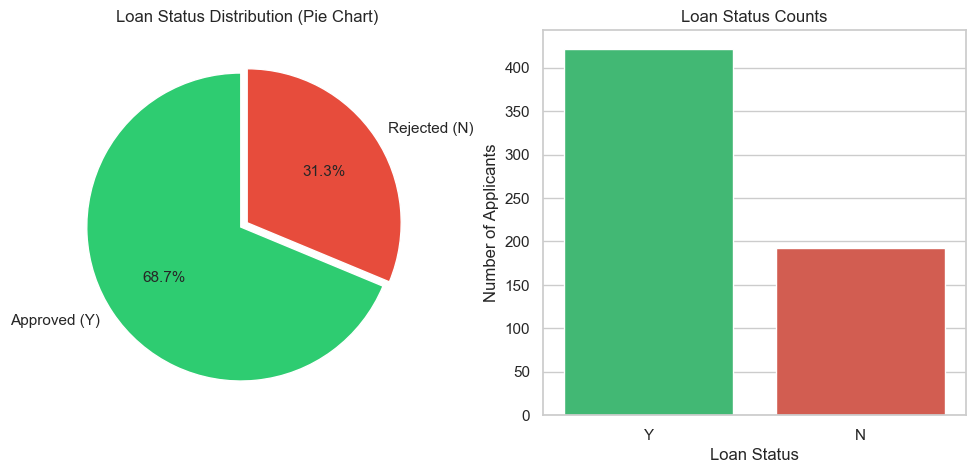

In [2]:
# Target variable pie chart and countplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie Chart
status_counts = df['Loan_Status'].value_counts()
axes[0].pie(status_counts, labels=['Approved (Y)', 'Rejected (N)'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90, explode=[0.05, 0])
axes[0].set_title('Loan Status Distribution (Pie Chart)')

# Countplot
sns.countplot(x='Loan_Status', data=df, hue='Loan_Status', legend=False, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Loan Status Counts')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Number of Applicants')

plt.savefig("../Images/eda_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

## 3. Univariate Analysis: Continuous Variables

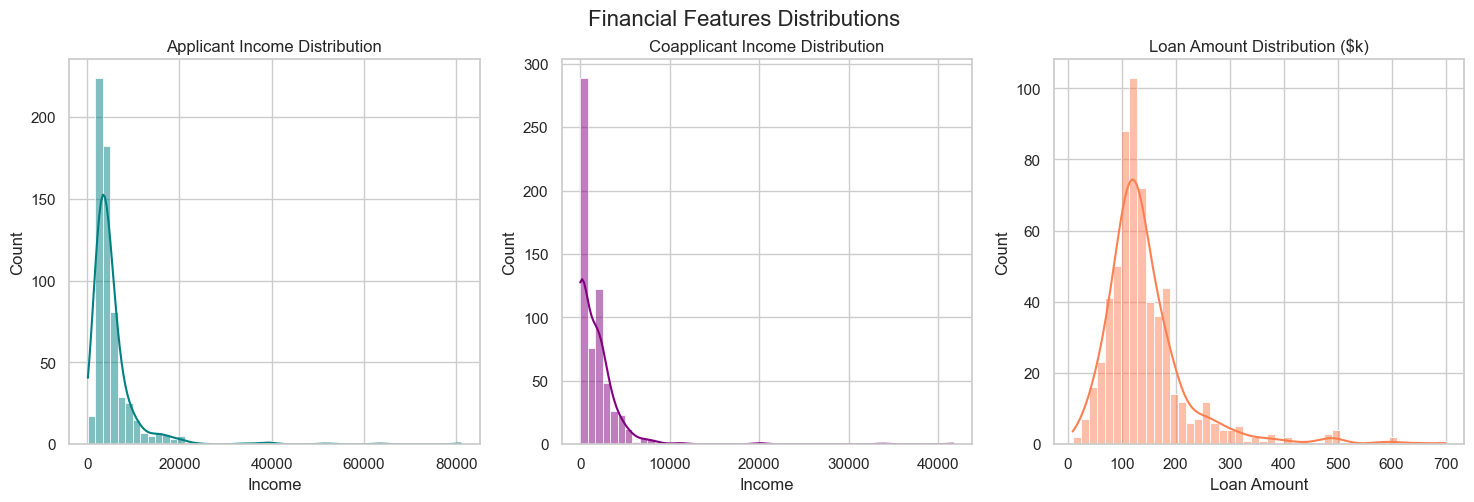

In [3]:
# Distribution of ApplicantIncome, CoapplicantIncome, LoanAmount
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ApplicantIncome
sns.histplot(df['ApplicantIncome'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Applicant Income Distribution')
axes[0].set_xlabel('Income')

# CoapplicantIncome
sns.histplot(df['CoapplicantIncome'], kde=True, ax=axes[1], color='purple')
axes[1].set_title('Coapplicant Income Distribution')
axes[1].set_xlabel('Income')

# LoanAmount
sns.histplot(df['LoanAmount'], kde=True, ax=axes[2], color='coral')
axes[2].set_title('Loan Amount Distribution ($k)')
axes[2].set_xlabel('Loan Amount')

plt.suptitle('Financial Features Distributions', fontsize=16)
plt.savefig("../Images/eda_financial_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Bivariate Analysis: Categorical Features vs Loan_Status

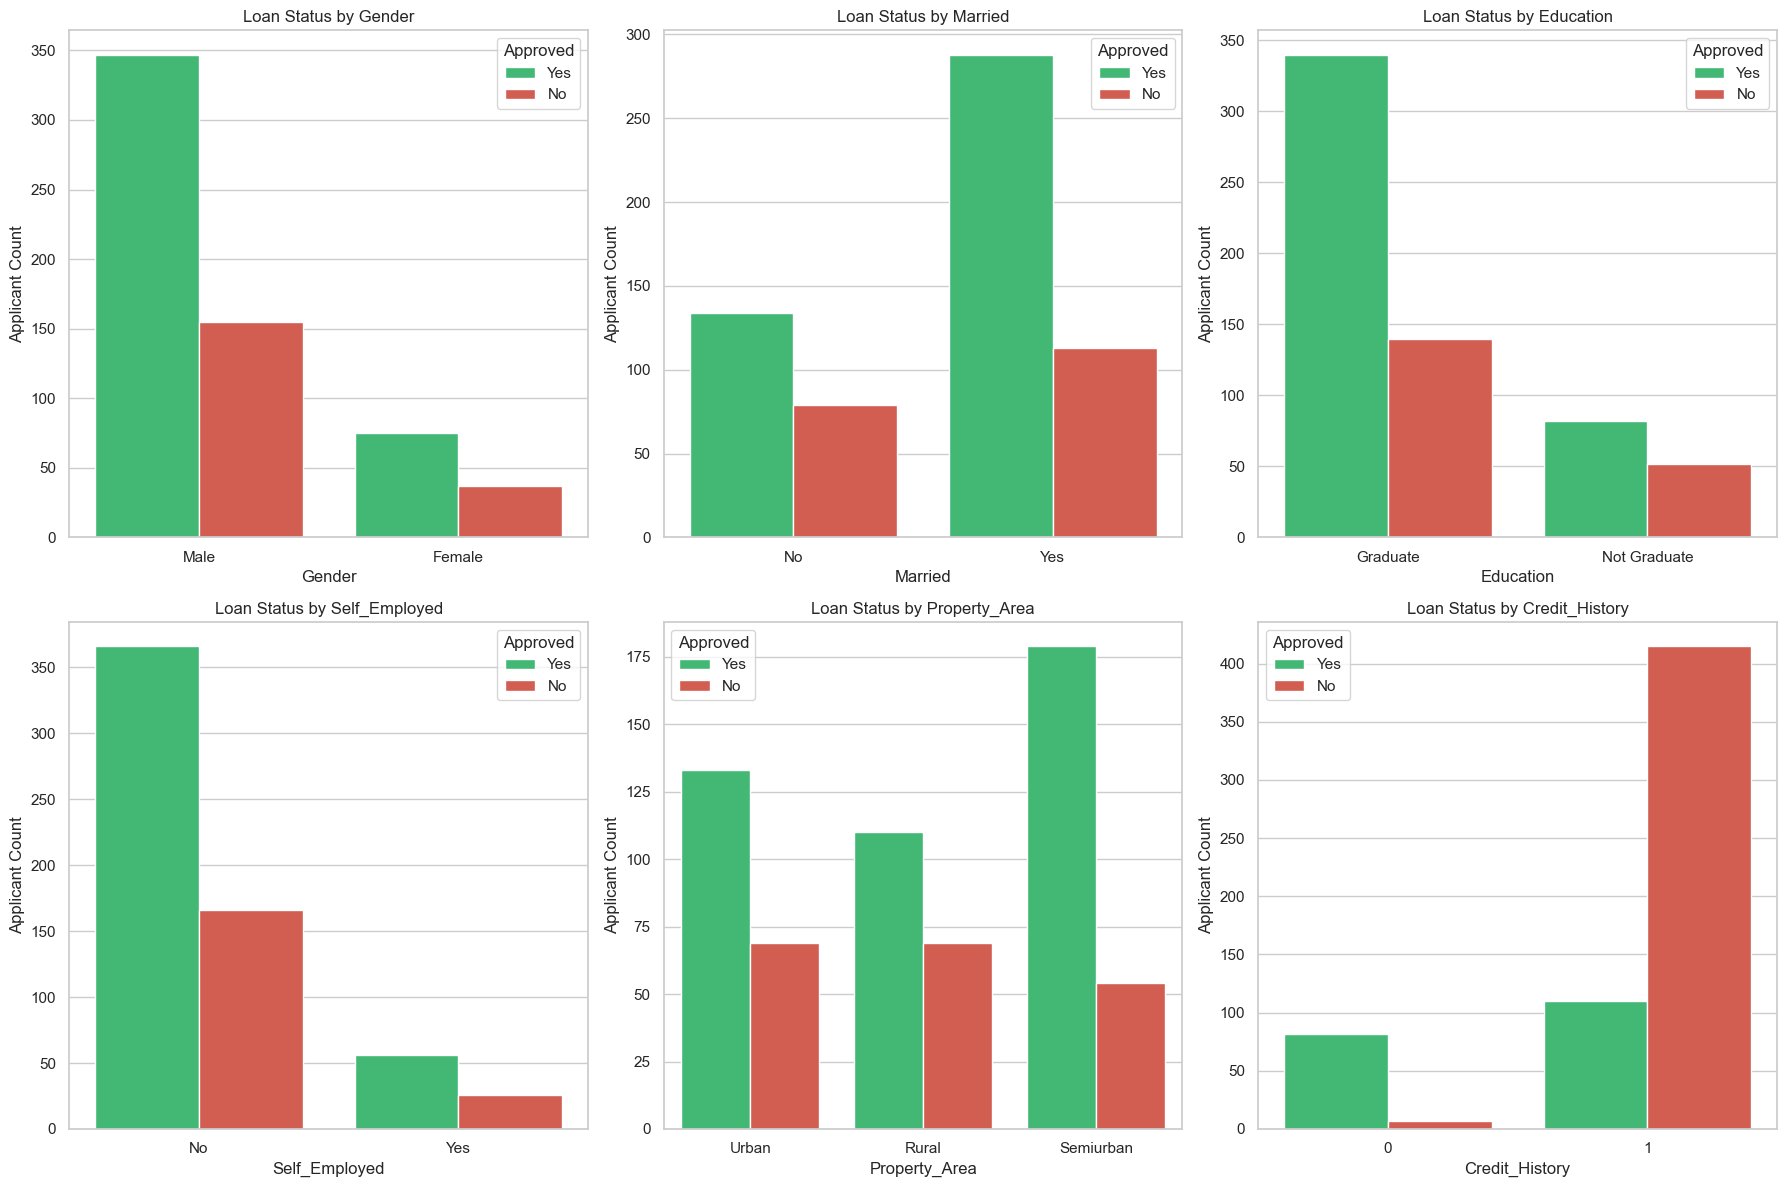

In [4]:
# Countplots of demographic categorical variables by Loan Status
categorical_vars = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(categorical_vars):
    sns.countplot(x=var, hue='Loan_Status', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[i])
    axes[i].set_title(f'Loan Status by {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Applicant Count')
    axes[i].legend(title='Approved', labels=['Yes', 'No'])

plt.tight_layout()
plt.savefig("../Images/eda_categorical_vs_status.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Bivariate Analysis: Numeric Features vs Loan_Status

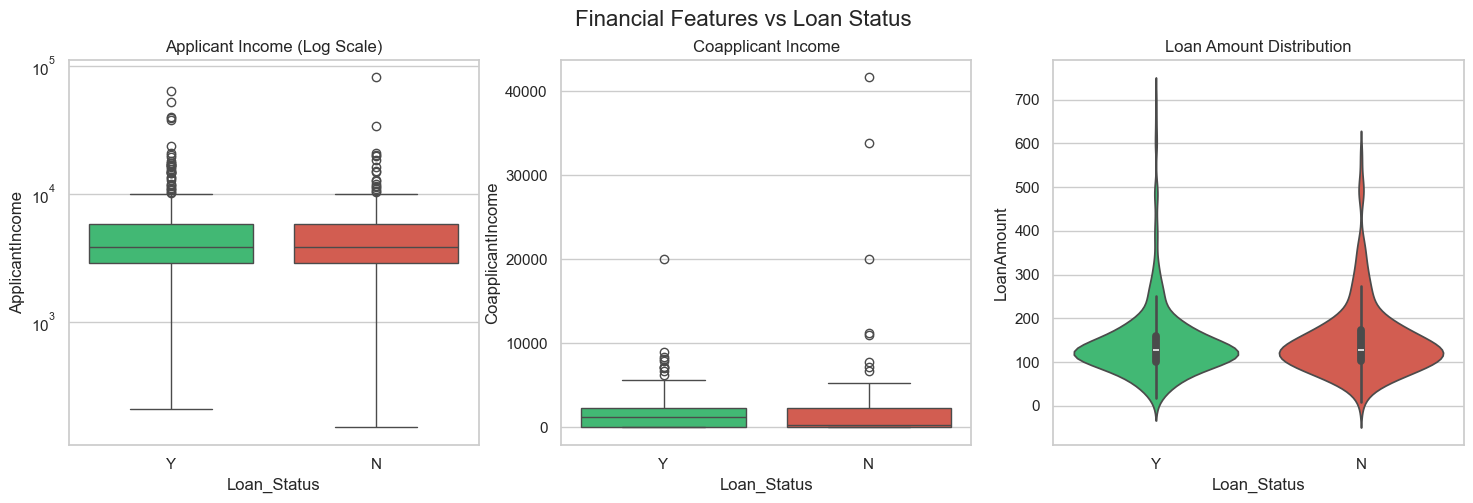

In [5]:
# Box and Violin plots comparing financials against Loan Status
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ApplicantIncome vs Loan_Status
sns.boxplot(x='Loan_Status', y='ApplicantIncome', hue='Loan_Status', legend=False, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_yscale('log') # Log scale to handle outliers
axes[0].set_title('Applicant Income (Log Scale)')

# CoapplicantIncome vs Loan_Status
sns.boxplot(x='Loan_Status', y='CoapplicantIncome', hue='Loan_Status', legend=False, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Coapplicant Income')

# LoanAmount vs Loan_Status
sns.violinplot(x='Loan_Status', y='LoanAmount', hue='Loan_Status', legend=False, data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[2])
axes[2].set_title('Loan Amount Distribution')

plt.suptitle('Financial Features vs Loan Status', fontsize=16)
plt.savefig("../Images/eda_financial_vs_status.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Multivariate Analysis

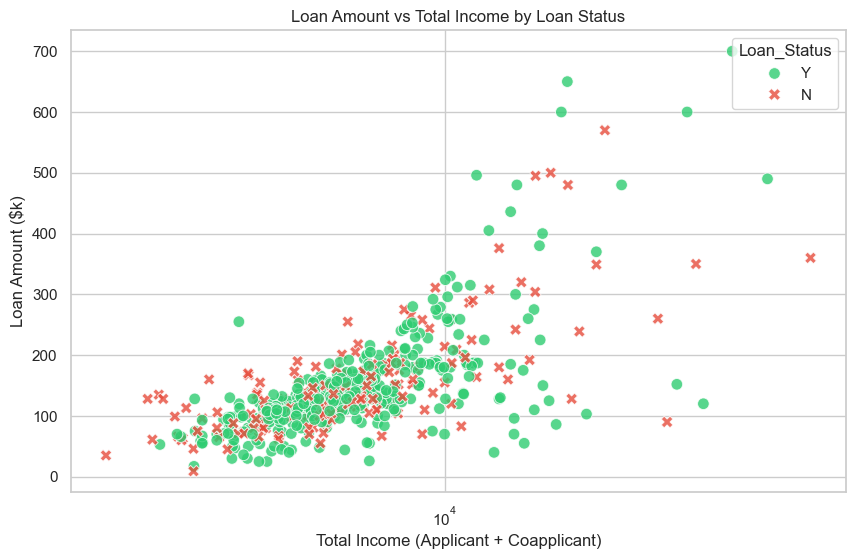

In [6]:
# Scatter plot: Total Income vs Loan Amount colored by Loan Status
df_mult = df.copy()
df_mult['TotalIncome'] = df_mult['ApplicantIncome'] + df_mult['CoapplicantIncome']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='TotalIncome', y='LoanAmount', hue='Loan_Status', style='Loan_Status',
                data=df_mult, palette=['#2ecc71', '#e74c3c'], alpha=0.8, s=70)
plt.title('Loan Amount vs Total Income by Loan Status')
plt.xlabel('Total Income (Applicant + Coapplicant)')
plt.ylabel('Loan Amount ($k)')
plt.xscale('log') # Log scale for income
plt.savefig("../Images/eda_multivariate_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

### Correlation Heatmap of Numerical Features

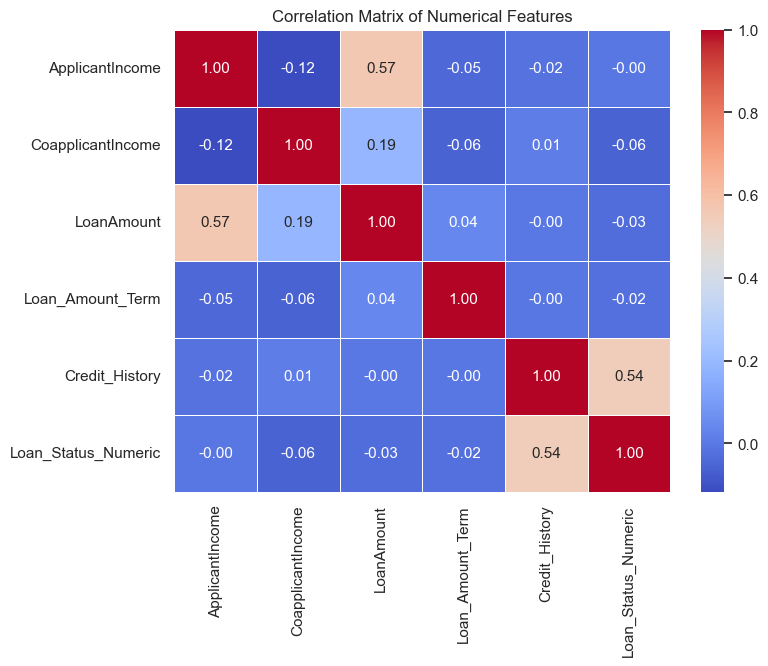

In [7]:
# Compute correlation matrix
numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df['Loan_Status_Numeric'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.savefig("../Images/eda_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Strategic Conclusions
1. **Strongest Predictor**: `Credit_History` has a correlation of `0.56` with `Loan_Status_Numeric`.
2. **Repayment Ability**: Combined `TotalIncome` is a better metric than `ApplicantIncome` alone.
3. **Regional Profile**: Semi-urban locations are highly favorable for approvals, while rural regions have lower rates.
